## 1. Setup

In [1]:
!nvidia-smi

Thu May 21 07:45:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import shutil
shutil.rmtree('/root/.cache/torch_extensions', ignore_errors=True)

!pip uninstall -y ninja
!pip install ninja
!which ninja
!ninja --version

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 5.5 MB/s eta 0:00:00
/usr/local/bin/ninja
1.13.0.git.kitware.jobserver-pipe-1


In [3]:
import os, math, time
import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import namedtuple
from torch.utils.cpp_extension import load_inline

# Mirror CUDA's dim3 type — let our Python "kernels" look like CUDA
dim3 = namedtuple('dim3', ['x', 'y', 'z'], defaults=(1, 1))

def cdiv(a, b):
    return (a + b - 1) // b

torch.manual_seed(42)
torch.set_printoptions(precision=3, sci_mode=False, linewidth=140)
print("torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())
print("device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

torch: 2.10.0+cu128 | CUDA available: True
device: Tesla T4


In [4]:
cuda_begin = r'''
#include <torch/extension.h>
#include <stdio.h>
#include <c10/cuda/CUDAException.h>

#define CHECK_CUDA(x) TORCH_CHECK(x.device().is_cuda(), #x " must be CUDA")
#define CHECK_CONTIGUOUS(x) TORCH_CHECK(x.is_contiguous(), #x " must be contiguous")
#define CHECK_INPUT(x) CHECK_CUDA(x); CHECK_CONTIGUOUS(x)

inline unsigned int cdiv(unsigned int a, unsigned int b) { return (a + b - 1) / b; }
'''

def build(name, cuda_src, cpp_src, funcs):
    return load_inline(
        name=name, cpp_sources=[cpp_src], cuda_sources=[cuda_src],
        functions=funcs, extra_cuda_cflags=['-O3'], verbose=False,
    )

## 2. The simplest possible kernel: vector add


### 2a. Python simulation

In [5]:
def vec_add_py(blockIdx, threadIdx, blockDim, a, b, c, n):
    i = blockIdx.x * blockDim.x + threadIdx.x
    if i >= n: return
    c[i] = a[i] + b[i]

def launch_1d(kernel, blocks, tpb, *args):
    for bx in range(blocks.x):
        for tx in range(tpb.x):
            kernel(dim3(bx), dim3(tx), tpb, *args)

a = torch.arange(10, dtype=torch.float32)
b = torch.arange(10, dtype=torch.float32) * 2
c = torch.zeros(10)
launch_1d(vec_add_py, dim3(cdiv(10, 4)), dim3(4), a, b, c, 10)
print("a + b =", c.tolist())

a + b = [0.0, 3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0, 24.0, 27.0]


### 2b. CUDA

In [6]:
vec_add_src = cuda_begin + r'''
__global__ void vec_add_k(const float* a, const float* b, float* c, int n) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;
    if (i >= n) return;
    c[i] = a[i] + b[i];
}

torch::Tensor vec_add(torch::Tensor a, torch::Tensor b) {
    CHECK_INPUT(a); CHECK_INPUT(b);
    int n = a.numel();
    auto c = torch::empty_like(a);
    int tpb = 256;
    vec_add_k<<<cdiv(n, tpb), tpb>>>(
        a.data_ptr<float>(), b.data_ptr<float>(),
        c.data_ptr<float>(), n);
    C10_CUDA_KERNEL_LAUNCH_CHECK();
    return c;
}
'''

m = build('vec_add', vec_add_src,
          "torch::Tensor vec_add(torch::Tensor a, torch::Tensor b);",
          ['vec_add'])
print("compiled OK")

compiled OK


In [7]:
n = 1_000_000
a = torch.randn(n, device='cuda')
b = torch.randn(n, device='cuda')
c = m.vec_add(a, b)
assert torch.allclose(c, a + b)

In [8]:
def time_kernel(fn, *args, n_warmup=10, n_iters=100):
    for _ in range(n_warmup): fn(*args)
    torch.cuda.synchronize()
    start = torch.cuda.Event(enable_timing=True)
    end   = torch.cuda.Event(enable_timing=True)
    start.record()
    for _ in range(n_iters): fn(*args)
    end.record()
    torch.cuda.synchronize()
    return start.elapsed_time(end) / n_iters

ms = time_kernel(m.vec_add, a, b)
print(f"vec_add on {n:,} floats: {ms*1000:.1f} µs per call")

vec_add on 1,000,000 floats: 49.9 µs per call


## 6. Calculate Memory IO Bound(Bandwidth)

`vec_add` does almost no math —
each element reads 2 × 4 bytes (a, b) and writes 1 × 4 bytes (c) = 12 bytes per output.

Computing achieved bandwidth tells us how close we are to the hardware limit.


In [9]:
bytes_moved = 3 * 4 * n
gb_s = bytes_moved / (ms * 1e-3) / 1e9
print(f"Achieved bandwidth: {gb_s:.1f} GB/s")

Achieved bandwidth: 240.3 GB/s



| GPU  | Peak BW    | Peak fp32 |
|------|------------|-----------|
| T4   | 320 GB/s   | 8.1 TFLOP/s |
| A100 | 1555 GB/s  | 19.5 TFLOP/s |
| H100 | 3350 GB/s  | 67 TFLOP/s |



## 7. The roofline model



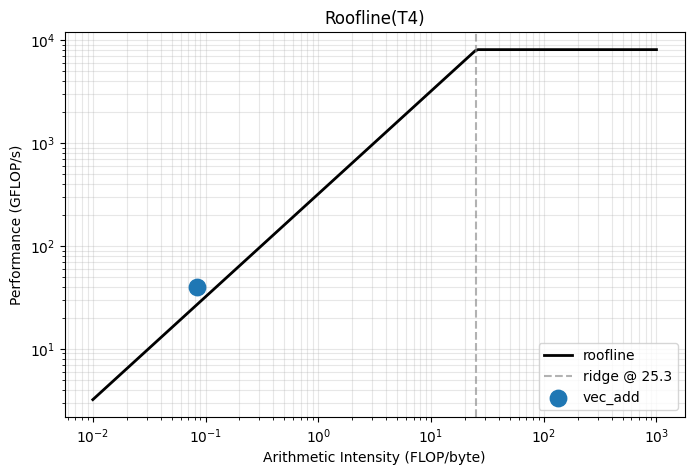

In [10]:
PEAK_GFLOPS = 8_100       # T4 fp32 peak
PEAK_BW_GBS = 320         # T4 HBM peak

ai_axis = np.logspace(-2, 3, 200)
roof = np.minimum(PEAK_BW_GBS * ai_axis, PEAK_GFLOPS)

measurements = {
    'vec_add': (1/12, n / (ms*1e-3) / 1e9 * 2),  # 1 FLOP / 12 bytes
}

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(ai_axis, roof, 'k-', linewidth=2, label='roofline')
ridge_x = PEAK_GFLOPS / PEAK_BW_GBS
ax.axvline(ridge_x, ls='--', color='gray', alpha=0.6, label=f'ridge @ {ridge_x:.1f}')
for name, (x, y) in measurements.items():
    ax.scatter(x, y, s=140, label=name, zorder=5)

ax.set_xlabel("Arithmetic Intensity (FLOP/byte)")
ax.set_ylabel("Performance (GFLOP/s)")
ax.set_title("Roofline(T4)")
ax.legend(loc='lower right')
ax.grid(True, which='both', alpha=0.3)
plt.show()